# IQueue — Demand Forecasting (Prophet + LSTM Hybrid)
## Cell 0: Environment Setup & Runtime Detection


In [1]:
import json, os, sys, warnings, zipfile, math
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
np.random.seed(42)

IS_KAGGLE = "kaggle" in sys.modules
IS_COLAB = "google.colab" in sys.modules

if IS_KAGGLE:
    BASE_DIR = Path("/kaggle/working/")
    INPUT_DIR = Path("/kaggle/input/datasets/aaronjalapon1/bus-ridership")
else:
    BASE_DIR = Path("/kaggle/working/")
    INPUT_DIR = Path("/kaggle/input/datasets/aaronjalapon1/bus-ridership")

ARTIFACTS_DIR = BASE_DIR / "artifacts"
PLOTS_DIR = BASE_DIR / "plots"
DATA_DIR = BASE_DIR / "data" / "raw"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:    {torch.version.cuda}")
    device = torch.device("cuda")
    USE_AMP = True
else:
    device = torch.device("cpu")
    USE_AMP = False
    print("GPU:             None (CPU-only mode)")
print(f"Device:          {device}")
print(f"IS_KAGGLE:       {IS_KAGGLE}")
print(f"BASE_DIR:        {BASE_DIR}")


PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             Tesla T4
CUDA version:    12.8
Device:          cuda
IS_KAGGLE:       False
BASE_DIR:        /kaggle/working


## Cell 1: Dependency Installation


In [2]:
# Install forecasting dependencies.
# On Kaggle these are typically pre-installed; this cell ensures pinned versions.
import subprocess, sys

def pip_install(packages):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + packages
    )

# Only install if not already present (skip on Kaggle for speed)
try:
    import prophet
    prophet_v = prophet.__version__ if hasattr(prophet, "__version__") else "installed"
    print(f"prophet already {prophet_v}")
except ImportError:
    pip_install(["prophet==1.1.5"])
    import prophet

try:
    import joblib
    print(f"joblib already {joblib.__version__}")
except ImportError:
    pip_install(["joblib==1.4.2"])

try:
    import sklearn
    print(f"scikit-learn already {sklearn.__version__}")
except ImportError:
    pip_install(["scikit-learn==1.5.0"])

print("All dependencies ready.")


prophet already 1.3.0
joblib already 1.5.3
scikit-learn already 1.6.1
All dependencies ready.


## Cell 2: Route Definitions & Data Loading


In [3]:
# ── Route Definitions ─────────────────────────────────────────────────────
ROUTES = [
    {"id": "davao-cagayan",         "label": "Davao → Cagayan de Oro",   "base_pax": 420},
    {"id": "davao-cotabato",        "label": "Davao → Cotabato City",    "base_pax": 280},
    {"id": "davao-general-santos",  "label": "Davao → General Santos",   "base_pax": 350},
    {"id": "cagayan-iligan",        "label": "Cagayan de Oro → Iligan",  "base_pax": 190},
    {"id": "davao-butuan",          "label": "Davao → Butuan",           "base_pax": 310},
    {"id": "cotabato-zambo",        "label": "Cotabato → Zamboanga",     "base_pax": 160},
]

ROUTE_IDS = [r["id"] for r in ROUTES]
ROUTE_BASE_PAX = {r["id"]: r["base_pax"] for r in ROUTES}
ROUTE_LABELS = {r["id"]: r["label"] for r in ROUTES}

# ── Surge Event Definitions ──────────────────────────────────────────────
SURGE_EVENTS = [
    {"name": "Holy Week",        "type": "fixed_window", "month": 4,  "days": list(range(1, 8)),  "mult": 3.2},
    {"name": "Christmas",        "type": "fixed_window", "month": 12, "days": list(range(22, 28)), "mult": 3.5},
    {"name": "New Year",         "type": "fixed_window", "month": 1,  "days": list(range(1, 4)),  "mult": 2.8},
    {"name": "All Saints Day",   "type": "fixed_window", "month": 11, "days": list(range(1, 3)),  "mult": 3.0},
    {"name": "Independence Day", "type": "fixed_window", "month": 6,  "days": [12],                 "mult": 1.8},
    {"name": "Eid al-Fitr",      "type": "fixed_window", "month": 4,  "days": list(range(9, 12)), "mult": 2.5},
    {"name": "Hariraya",         "type": "fixed_window", "month": 4,  "days": list(range(9, 12)), "mult": 2.5},
]

# Build lookup: (month, day) -> (mult, name)
SURGE_MAP = {}
for ev in SURGE_EVENTS:
    for d in ev["days"]:
        key = (ev["month"], d)
        if key not in SURGE_MAP or ev["mult"] > SURGE_MAP[key][0]:
            SURGE_MAP[key] = (ev["mult"], ev["name"])

# ── Date Range ───────────────────────────────────────────────────────────
START_DATE = datetime(2022, 1, 1)
END_DATE   = datetime(2024, 12, 31)
ALL_DATES  = pd.date_range(START_DATE, END_DATE, freq="D")

print(f"Date range: {START_DATE.date()} → {END_DATE.date()}")
print(f"Total days:  {len(ALL_DATES)}")
print(f"Expected rows: {len(ALL_DATES) * len(ROUTES)}")

# ── Load pre-generated synthetic data ───────────────────────────────────
# On Kaggle: reads from /kaggle/input/iqueue-forecasting/ridership_synthetic.csv
# Locally:   reads from ml/forecasting/data/raw/ridership_synthetic.csv
#
# Generate the CSV locally before running this notebook:
#   python ml/forecasting/generate_training_data.py \
#     --kaggle-data ml/forecasting/data/kaggle-bus-ridership.CSV \
#     --output-dir ml/forecasting/data/raw/
CSV_PATH = INPUT_DIR / "ridership_synthetic.csv"
LOCAL_CSV = DATA_DIR / "ridership_synthetic.csv"  # fallback for local runs

if CSV_PATH.exists():
    print(f"Loading data from Kaggle input: {CSV_PATH}")
    df_all = pd.read_csv(CSV_PATH, parse_dates=["date"])
elif LOCAL_CSV.exists():
    print(f"Loading data from local path: {LOCAL_CSV}")
    df_all = pd.read_csv(LOCAL_CSV, parse_dates=["date"])
else:
    raise FileNotFoundError(
        f"\n{'='*60}\n"
        f"  Synthetic data NOT FOUND.\n"
        f"  Tried: {CSV_PATH}\n"
        f"  Tried: {LOCAL_CSV}\n\n"
        f"  Generate it locally first:\n"
        f"    python ml/forecasting/generate_training_data.py \\\n"
        f"      --kaggle-data ml/forecasting/data/kaggle-bus-ridership.CSV \\\n"
        f"      --output-dir ml/forecasting/data/raw/\n\n"
        f"  For Kaggle: upload ridership_synthetic.csv as dataset\n"
        f"  'iqueue-forecasting'.\n"
        f"{'='*60}"
    )

print(f"\nTotal rows: {len(df_all)}")
print(f"Columns:    {list(df_all.columns)}")
print(f"Routes:     {df_all['route_id'].nunique()}")
print(f"Date range: {df_all['date'].min().date()} → {df_all['date'].max().date()}")
print(f"\nSample:")
display(df_all.head(10))


Date range: 2022-01-01 → 2024-12-31
Total days:  1096
Expected rows: 6576
Loading data from Kaggle input: /kaggle/input/datasets/aaronjalapon1/bus-ridership/ridership_synthetic.csv

Total rows: 6576
Columns:    ['date', 'route_id', 'route_label', 'passenger_count', 'is_holiday', 'holiday_name', 'day_of_week', 'is_weekend', 'is_terminal_closure']
Routes:     6
Date range: 2022-01-01 → 2024-12-31

Sample:


,date,route_id,route_label,passenger_count,is_holiday,holiday_name,day_of_week,is_weekend,is_terminal_closure
0,2022-01-01,davao-cagayan,Davao → Cagayan de Oro,1015,1,New Year,5,1,0
1,2022-01-02,davao-cagayan,Davao → Cagayan de Oro,1290,1,New Year,6,1,0
2,2022-01-03,davao-cagayan,Davao → Cagayan de Oro,700,1,New Year (ramp-down),0,0,0
3,2022-01-04,davao-cagayan,Davao → Cagayan de Oro,344,0,none,1,0,0
4,2022-01-05,davao-cagayan,Davao → Cagayan de Oro,345,0,none,2,0,0
5,2022-01-06,davao-cagayan,Davao → Cagayan de Oro,341,0,none,3,0,0
6,2022-01-07,davao-cagayan,Davao → Cagayan de Oro,488,0,none,4,0,0
7,2022-01-08,davao-cagayan,Davao → Cagayan de Oro,400,0,none,5,1,0
8,2022-01-09,davao-cagayan,Davao → Cagayan de Oro,0,0,none,6,1,1
9,2022-01-10,davao-cagayan,Davao → Cagayan de Oro,0,0,none,0,0,1


## Cell 3: EDA & Visual Validation


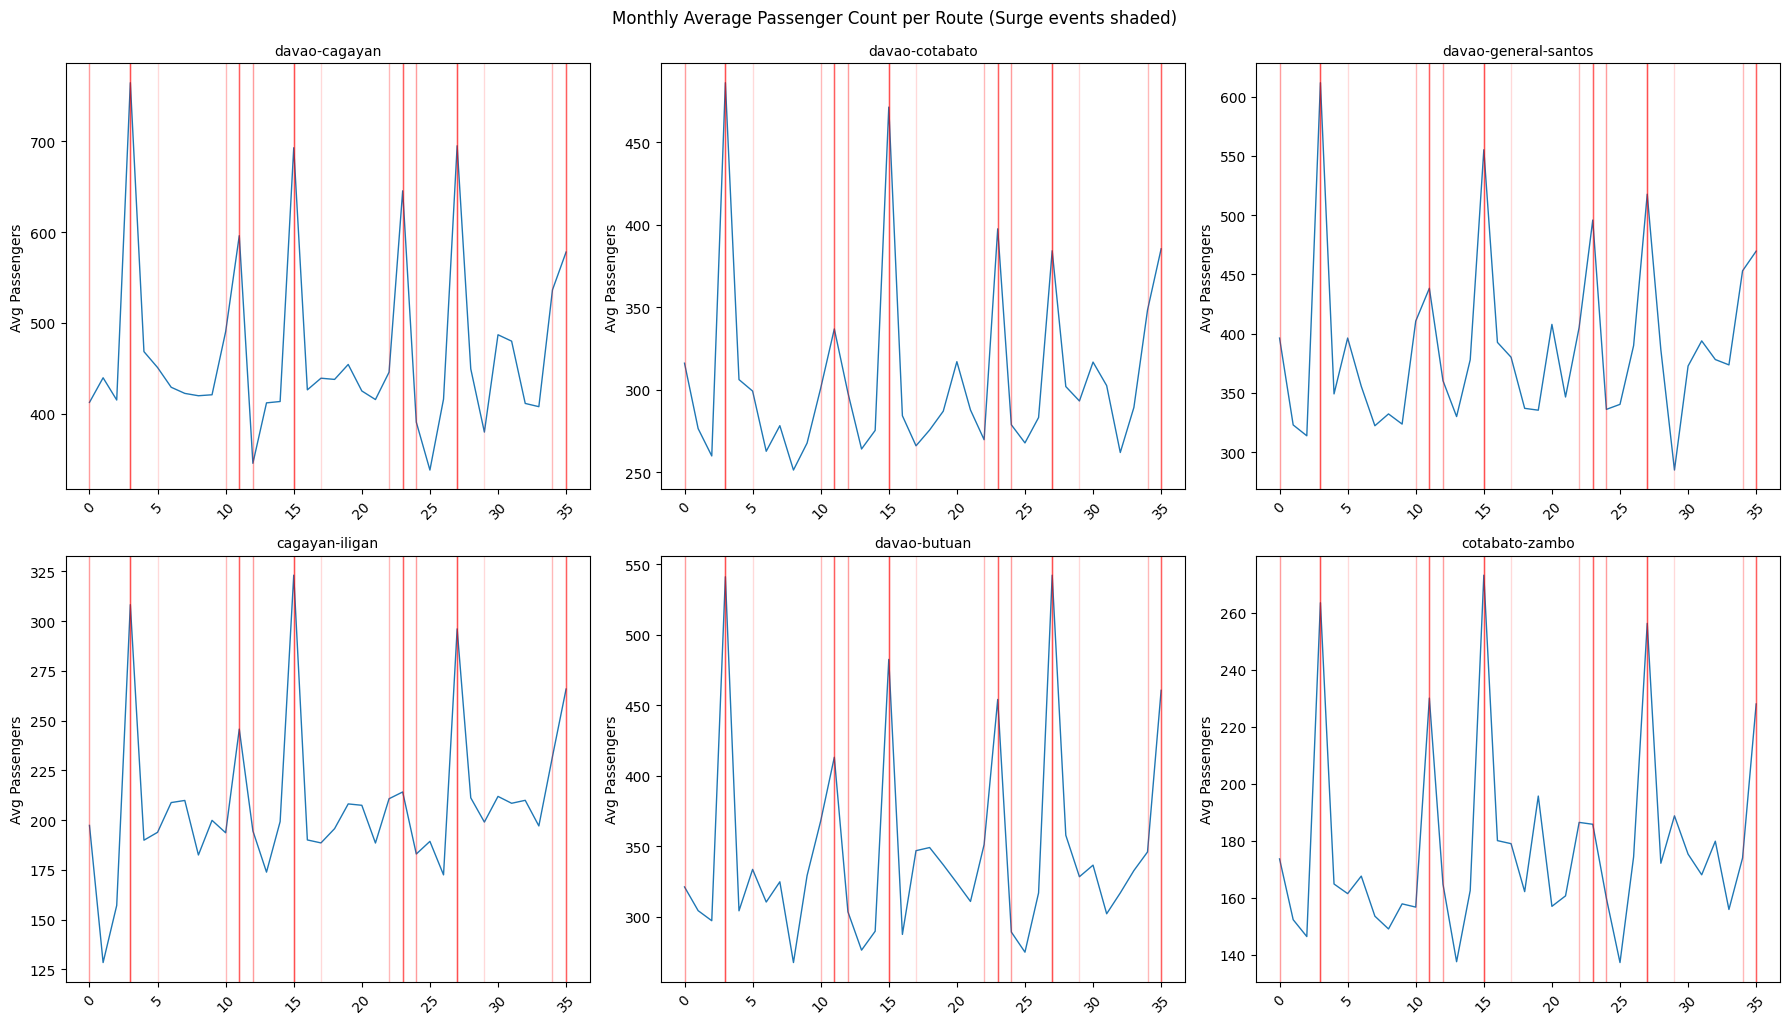


Terminal closures: 200 / 6576 (3.04%)

Route: davao-cagayan (Davao → Cagayan de Oro)
Non-closure days: 1056
Surge days:       82
count    1056.000000
mean      485.820076
std       214.411682
min       228.000000
25%       383.000000
50%       428.500000
75%       499.250000
max      1899.000000
Name: passenger_count, dtype: float64
Median:           428
Surge threshold:  771

Route: davao-cotabato (Davao → Cotabato City)
Non-closure days: 1067
Surge days:       83
count    1067.000000
mean      315.185567
std       135.526225
min       142.000000
25%       249.000000
50%       282.000000
75%       328.000000
max      1178.000000
Name: passenger_count, dtype: float64
Median:           282
Surge threshold:  508

Route: davao-general-santos (Davao → General Santos)
Non-closure days: 1063
Surge days:       84
count    1063.000000
mean      400.679210
std       174.124459
min       172.000000
25%       312.000000
50%       358.000000
75%       414.000000
max      1481.000000
Name: passeng

In [4]:
# ── Monthly passenger count per route ────────────────────────────────────
df_all["year_month"] = df_all["date"].dt.to_period("M")

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for idx, rid in enumerate(ROUTE_IDS):
    rdf = df_all[df_all["route_id"] == rid]
    monthly = rdf.groupby("year_month")["passenger_count"].mean().reset_index()
    monthly["year_month"] = monthly["year_month"].astype(str)
    ax = axes[idx]
    ax.plot(range(len(monthly)), monthly["passenger_count"], linewidth=1)
    ax.set_title(rid, fontsize=10)
    ax.set_ylabel("Avg Passengers")
    ax.tick_params(axis="x", rotation=45)

    # Overlay surge event windows as shaded regions
    for ev in SURGE_EVENTS:
        if ev["name"] in ("Eid al-Fitr", "Hariraya"):
            continue  # skip duplicates
        for year in [2022, 2023, 2024]:
            for d in ev["days"]:
                try:
                    sd = datetime(year, ev["month"], d)
                    if START_DATE <= sd <= END_DATE:
                        mp = sd.strftime("%Y-%m")
                        if mp in monthly["year_month"].values:
                            xi = monthly[monthly["year_month"] == mp].index[0]
                            ax.axvline(xi, color="red", alpha=0.15, linewidth=1)
                except ValueError:
                    pass

fig.tight_layout()
plt.suptitle("Monthly Average Passenger Count per Route (Surge events shaded)", y=1.02)
plt.show()

# ── Closure distribution ─────────────────────────────────────────────────
closures = df_all[df_all["is_terminal_closure"] == 1]
print(f"\nTerminal closures: {len(closures)} / {len(df_all)} ({len(closures) / len(df_all) * 100:.2f}%)")

# ── Per-route describe ───────────────────────────────────────────────────
for rid in ROUTE_IDS:
    rdf = df_all[(df_all["route_id"] == rid) & (df_all["is_terminal_closure"] == 0)]
    print(f"\n{'='*60}")
    print(f"Route: {rid} ({ROUTE_LABELS[rid]})")
    print(f"Non-closure days: {len(rdf)}")
    print(f"Surge days:       {rdf['is_holiday'].sum()}")
    print(rdf["passenger_count"].describe())
    print(f"Median:           {rdf['passenger_count'].median():.0f}")
    print(f"Surge threshold:  {rdf['passenger_count'].median() * 1.8:.0f}")

# ── Surge spike magnitude per route ──────────────────────────────────────
for rid in ROUTE_IDS:
    rdf = df_all[(df_all["route_id"] == rid) & (df_all["is_terminal_closure"] == 0)]
    non_surge = rdf[rdf["is_holiday"] == 0]["passenger_count"]
    surge = rdf[rdf["is_holiday"] == 1]["passenger_count"]
    if len(surge) > 0:
        spike = surge.mean() / non_surge.mean() if non_surge.mean() > 0 else 0
        print(f"  {rid:25s} | Non-surge mean: {non_surge.mean():7.0f} | Surge mean: {surge.mean():7.0f} | Spike: {spike:.2f}x")


## Cell 4: Preprocessing Pipeline


In [5]:
from sklearn.preprocessing import MinMaxScaler
import joblib

def preprocess(route_id: str, lookback: int = 14) -> dict:
    """Preprocess raw synthetic data into Prophet + LSTM ready format.

    Returns dict with keys:
        prophet_df, lstm_train, lstm_val, y_train, y_val, scaler,
        train_dates, val_dates, route_median, daily_dates, feature_cols,
        n_days, split_idx
    """
    rdf = df_all[df_all["route_id"] == route_id].copy()
    rdf = rdf.sort_values("date").reset_index(drop=True)

    # 1. Drop terminal closures
    rdf = rdf[rdf["is_terminal_closure"] == 0].copy()

    # 2. Reindex to full daily DatetimeIndex; fill gaps with 7-day rolling mean
    rdf = rdf.set_index("date")
    full_idx = pd.date_range(rdf.index.min(), rdf.index.max(), freq="D")
    rdf = rdf.reindex(full_idx)
    rdf["passenger_count"] = rdf["passenger_count"].fillna(
        rdf["passenger_count"].rolling(7, min_periods=1, center=True).mean()
    )
    rdf["is_holiday"] = rdf["is_holiday"].fillna(0).astype(int)
    rdf["is_weekend"] = rdf["is_weekend"].fillna(0).astype(int)
    rdf["day_of_week"] = rdf.index.dayofweek
    rdf["route_id"] = route_id
    rdf["route_label"] = ROUTE_LABELS[route_id]
    rdf["holiday_name"] = rdf["holiday_name"].fillna("none")
    rdf["is_terminal_closure"] = rdf["is_terminal_closure"].fillna(0).astype(int)

    # 3. Outlier clamping: use 99.5th percentile instead of mean+4*std.
    #    mean+4*std is inflated by surge events and clips ~2-3% of surge
    #    peaks by ~30%, destroying the signal the model needs to learn.
    #    99.5th percentile only affects the most extreme 0.5% of values
    #    while preserving surge magnitude information.
    cap = float(np.percentile(rdf["passenger_count"].values, 99.5))
    n_clamped = (rdf["passenger_count"] > cap).sum()
    if n_clamped > 0:
        print(f"  [{route_id}] Clamping {n_clamped} outliers above {cap:.0f} "
              f"(99.5th pct, vs old mean+4σ={rdf['passenger_count'].mean() + 4*rdf['passenger_count'].std():.0f})")
    rdf["passenger_count"] = rdf["passenger_count"].clip(upper=cap)

    route_median = rdf["passenger_count"].median()

    # 4. Prophet format (includes holiday flags for correct Prophet inference)
    prophet_df = rdf.reset_index()[["index", "passenger_count", "is_holiday"]].copy()
    prophet_df.columns = ["ds", "y", "is_holiday"]

    # 5. LSTM features — enriched with calendar signals
    rdf["dow_sin"] = np.sin(2 * np.pi * rdf["day_of_week"] / 7)
    rdf["dow_cos"] = np.cos(2 * np.pi * rdf["day_of_week"] / 7)
    # Month-of-year: helps model learn seasonal holiday patterns (e.g. Dec, Apr)
    rdf["month_sin"] = np.sin(2 * np.pi * rdf.index.month / 12)
    rdf["month_cos"] = np.cos(2 * np.pi * rdf.index.month / 12)
    # Day-of-month: helps model anticipate month-end travel surges
    rdf["day_of_month"] = (rdf.index.day - 1) / 30.0  # normalised 0–1

    feature_cols = [
        "passenger_count", "is_holiday", "dow_sin", "dow_cos", "is_weekend",
        "month_sin", "month_cos", "day_of_month",
    ]
    data = rdf[feature_cols].values.astype(np.float32)

    # 6. Fit MinMaxScaler on train split only
    split_idx = int(len(data) * 0.8)
    train_data = data[:split_idx]
    val_data = data[split_idx:]

    scaler = MinMaxScaler()
    scaler.fit(train_data)

    train_scaled = scaler.transform(train_data)
    val_scaled = scaler.transform(val_data)

    # 7. Build sequences
    def build_sequences(arr, lb):
        X, y = [], []
        for i in range(len(arr) - lb):
            X.append(arr[i : i + lb])
            y.append(arr[i + lb, 0])  # target = passenger_count
        return np.array(X), np.array(y)

    X_train, y_train = build_sequences(train_scaled, lookback)
    X_val, y_val = build_sequences(val_scaled, lookback)

    train_dates = rdf.index[lookback : lookback + len(X_train)]
    val_dates = rdf.index[split_idx + lookback : split_idx + lookback + len(X_val)]

    # Save scaler
    joblib.dump(scaler, ARTIFACTS_DIR / f"{route_id}_scaler.pkl")

    print(f"  [{route_id}] Train seqs: {X_train.shape}, Val seqs: {X_val.shape}")
    print(f"  [{route_id}] Lookback: {lookback}, Features: {X_train.shape[2]}")

    return {
        "prophet_df": prophet_df,
        "lstm_train": X_train,
        "lstm_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "scaler": scaler,
        "train_dates": train_dates,
        "val_dates": val_dates,
        "route_median": route_median,
        "feature_cols": feature_cols,
        "n_days": len(rdf),
        "split_idx": split_idx,
        "daily_dates": rdf.index,
    }

# Quick test on one route
test_pre = preprocess("davao-cagayan", lookback=14)
print(f"\nTest preprocess output keys: {list(test_pre.keys())}")
print(f"X_train shape: {test_pre['lstm_train'].shape}")
print(f"X_val shape:   {test_pre['lstm_val'].shape}")
print(f"Route median:  {test_pre['route_median']:.0f}")
print(f"Features:      {test_pre['feature_cols']}")

  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (862, 14, 5), Val seqs: (206, 14, 5)
  [davao-cagayan] Lookback: 14, Features: 5

Test preprocess output keys: ['prophet_df', 'lstm_train', 'lstm_val', 'y_train', 'y_val', 'scaler', 'train_dates', 'val_dates', 'route_median', 'feature_cols', 'n_days', 'split_idx', 'daily_dates']
X_train shape: (862, 14, 5)
X_val shape:   (206, 14, 5)
Route median:  429


## Cell 4.5: LightGBM Surge Classifier

Binary classifier that predicts whether tomorrow will be a surge day.
Uses tabular features (lags + calendar + rolling stats) — much more
data-efficient than the LSTM for binary classification of rare events.
Trained per route, saved to artifacts for inference.

In [ ]:
# ── Global LightGBM Surge Classifier ────────────────────────────────────────
# Trains ONE model for all 6 routes with route_id as a categorical feature.
# This gives ~400 positive examples instead of ~67 per route — enough for
# stable, discriminative probabilities across all routes.
#
# Target: will passenger_count(t+1) cross 1.8× route_median?

from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import precision_score, recall_score, f1_score

def build_surge_features_global(rdf: pd.DataFrame, route_id: str) -> tuple:
    """Build tabular features for surge classification, including route_id.

    Features at time t to predict above_threshold at time t+1:
      - passenger_count: current value + lags (1, 7, 14)
      - is_holiday: current holiday flag (captures ramp-up continuity)
      - Calendar features for TOMORROW (dow, weekend, month, day)
      - Rolling mean/std of passenger_count (7-day window)
      - Week-over-week pax change
      - route_id: categorical (handled natively by LightGBM)

    Returns (X, y, dates) or (None, None, None) if insufficient data.
    """
    n = len(rdf)
    if n < 16:
        return None, None, None

    rdf = rdf.copy()

    # Target: will passenger_count TOMORROW cross the surge threshold?
    route_median = rdf["passenger_count"].median()
    surge_threshold_val = 1.8 * route_median
    rdf["target_surge"] = (rdf["passenger_count"].shift(-1) >= surge_threshold_val).astype(int)

    # Passenger count lags
    rdf["pax_lag1"] = rdf["passenger_count"].shift(1)
    rdf["pax_lag7"] = rdf["passenger_count"].shift(7)
    rdf["pax_lag14"] = rdf["passenger_count"].shift(14)

    # Rolling statistics
    rdf["pax_roll_mean_7"] = rdf["passenger_count"].rolling(7, min_periods=1).mean()
    rdf["pax_roll_std_7"] = rdf["passenger_count"].rolling(7, min_periods=2).std().fillna(0)

    # Week-over-week change
    rdf["pax_wow_change"] = (rdf["passenger_count"] - rdf["pax_lag7"]) / (rdf["pax_lag7"] + 1)

    # Calendar features for TOMORROW
    rdf["dow_sin_t1"] = np.sin(2 * np.pi * ((rdf["day_of_week"] + 1) % 7) / 7)
    rdf["dow_cos_t1"] = np.cos(2 * np.pi * ((rdf["day_of_week"] + 1) % 7) / 7)
    rdf["is_weekend_t1"] = (((rdf["day_of_week"] + 1) % 7) >= 5).astype(int)

    rdf["month_t1"] = rdf.index.month
    rdf["month_sin_t1"] = np.sin(2 * np.pi * rdf["month_t1"] / 12)
    rdf["month_cos_t1"] = np.cos(2 * np.pi * rdf["month_t1"] / 12)
    rdf["day_of_month_t1"] = np.clip((rdf.index.day + 1) / 30.0, 0, 1.0)

    # Route ID as integer category
    rdf["route_cat"] = ROUTE_IDS.index(route_id)

    feature_cols = [
        "passenger_count", "is_holiday",
        "pax_lag1", "pax_lag7", "pax_lag14",
        "pax_roll_mean_7", "pax_roll_std_7", "pax_wow_change",
        "dow_sin_t1", "dow_cos_t1", "is_weekend_t1",
        "month_sin_t1", "month_cos_t1", "day_of_month_t1",
        "route_cat",
    ]

    valid = rdf.dropna(subset=feature_cols + ["target_surge"])
    if len(valid) < 10:
        return None, None, None

    X = valid[feature_cols].values.astype(np.float32)
    y = valid["target_surge"].values.astype(int)
    dates = valid.index

    return X, y, dates, feature_cols


# ── Build combined dataset from all 6 routes ────────────────────────────
print("Building global surge classifier dataset...")

all_X_train, all_y_train = [], []
all_X_val, all_y_val = [], []
val_info = {}  # route -> {X_val, y_val, dates}

for rid in ROUTE_IDS:
    rdf = df_all[df_all["route_id"] == rid].copy()
    rdf = rdf[rdf["is_terminal_closure"] == 0].sort_values("date").set_index("date")

    result = build_surge_features_global(rdf, rid)
    if result[0] is None:
        print(f"  [{rid}] SKIPPED — insufficient data")
        continue
    X, y, dates, feature_cols = result

    split_idx = int(len(X) * 0.8)
    all_X_train.append(X[:split_idx])
    all_y_train.append(y[:split_idx])
    all_X_val.append(X[split_idx:])
    all_y_val.append(y[split_idx:])
    val_info[rid] = {"X": X[split_idx:], "y": y[split_idx:], "dates": dates[split_idx:]}
    print(f"  [{rid}] {len(X)} samples, {y.sum()} surge ({y.mean()*100:.1f}%)")

X_train_full = np.concatenate(all_X_train)
y_train_full = np.concatenate(all_y_train)
X_val_full = np.concatenate(all_X_val)
y_val_full = np.concatenate(all_y_val)

print(f"\nGlobal training set: {len(X_train_full)} samples, "
      f"{y_train_full.sum()} surge ({y_train_full.mean()*100:.1f}%)")

# ── Train global LGBM ──────────────────────────────────────────────────
LGBM_PARAMS = {
    "n_estimators": 200,
    "max_depth": 4,
    "num_leaves": 31,
    "learning_rate": 0.03,
    "min_child_samples": 15,
    "is_unbalance": True,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "random_state": 42,
    "verbose": -1,
}

print(f"\nTraining global LGBM with params: {LGBM_PARAMS}")
clf = LGBMClassifier(**LGBM_PARAMS)
clf.fit(
    X_train_full, y_train_full,
    eval_set=[(X_val_full, y_val_full)],
    eval_metric="average_precision",
    callbacks=[early_stopping(30)],
)

# ── Evaluate per-route ─────────────────────────────────────────────────
print(f"\n{'='*70}")
print("Global LGBM — Per-Route Validation")
print(f"{'='*70}")

surge_clf_metrics = {}
for rid in ROUTE_IDS:
    if rid not in val_info:
        continue
    vi = val_info[rid]
    y_prob = clf.predict_proba(vi["X"])[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    y_val = vi["y"]

    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    n_surge = y_val.sum()
    n_triggered = y_pred.sum()

    surge_clf_metrics[rid] = {
        "precision": round(prec, 3), "recall": round(rec, 3),
        "f1": round(f1, 3), "n_val_surge": int(n_surge),
        "n_val_total": len(y_val), "n_triggered": int(n_triggered),
    }

    # Feature importance (global — from the full model)
    importances = clf.feature_importances_
    top_idx = np.argsort(importances)[-5:][::-1]
    top_features = ", ".join(f"{feature_cols[i]}={importances[i]:.3f}" for i in top_idx)

    print(f"  [{rid}] P={prec:.3f} R={rec:.3f} F1={f1:.3f} "
          f"triggered={n_triggered}/{len(y_val)} (surge={n_surge})")

print(f"\n  Top global features: {top_features}")

# Save global classifier
joblib.dump(clf, ARTIFACTS_DIR / "surge_clf_global.pkl")
joblib.dump(feature_cols, ARTIFACTS_DIR / "surge_clf_features.pkl")

# Save per-route metrics
with open(ARTIFACTS_DIR / "surge_clf_metrics.json", "w") as f:
    json.dump(surge_clf_metrics, f, indent=2)

print(f"\nGlobal surge classifier saved to {ARTIFACTS_DIR}/surge_clf_global.pkl")
print("Ready for combined inference.")


## Cell 5: Prophet Model


In [6]:
from prophet import Prophet

class IQueueProphetModel:
    def __init__(self, route_id: str):
        self.route_id = route_id
        self.model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.15,
            seasonality_prior_scale=10.0,
            holidays_prior_scale=20.0,
            seasonality_mode="multiplicative",
        )
        self.model.add_regressor("is_holiday", standardize=False)
        self._fitted = False

    def train(self, prophet_df: pd.DataFrame) -> None:
        self.model.fit(prophet_df[["ds", "y", "is_holiday"]])
        self._fitted = True
        print(f"  [Prophet:{self.route_id}] Trained on {len(prophet_df)} days")

    def predict(self, periods: int = 7) -> pd.DataFrame:
        if not self._fitted:
            raise RuntimeError("Model not trained")
        future = self.model.make_future_dataframe(periods=periods)
        # Add is_holiday for future dates (assume 0 for unknown future)
        future["is_holiday"] = 0
        forecast = self.model.predict(future)
        return forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

    def predict_on_dates(self, dates: pd.DatetimeIndex,
                         holiday_flags: np.ndarray = None) -> np.ndarray:
        """Predict yhat for specific dates, with optional holiday flags.

        Args:
            dates: DatetimeIndex of dates to predict for.
            holiday_flags: Optional 1-D array of is_holiday values (0/1)
                aligned with dates. If None, defaults to 0 (no holiday).
                Pass this for historical/in-sample dates where holiday
                labels are known (e.g. from the Prophet training dataframe).
        """
        if not self._fitted:
            raise RuntimeError("Model not trained")
        future = pd.DataFrame({"ds": dates})
        future["is_holiday"] = holiday_flags if holiday_flags is not None else 0
        forecast = self.model.predict(future)
        return forecast["yhat"].values

    def save(self, path: str) -> None:
        joblib.dump({"model": self.model, "route_id": self.route_id}, path)
        print(f"  [Prophet:{self.route_id}] Saved to {path}")

    @classmethod
    def load(cls, path: str) -> "IQueueProphetModel":
        data = joblib.load(path)
        inst = cls(data["route_id"])
        inst.model = data["model"]
        inst._fitted = True
        return inst

## Cell 6: LSTM Model


In [7]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

class PinballLoss(nn.Module):
    """Quantile regression loss (aka pinball loss).

    L(y, ŷ) = max(τ·(y−ŷ), (τ−1)·(y−ŷ))

    For τ > 0.5, under-prediction is penalised more heavily than
    over-prediction, so the model learns the τ-th conditional quantile
    rather than the conditional mean.  This directly targets surge
    detection: with τ = 0.90 the model predicts the 90th percentile,
    naturally crossing the surge threshold on high-demand days.

    Args:
        quantile: Target quantile in (0, 1).  Default 0.90 for surge.
    """
    def __init__(self, quantile: float = 0.90):
        super().__init__()
        self.quantile = quantile

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        errors = target - pred  # actual − predicted
        return torch.mean(
            torch.maximum(self.quantile * errors,
                          (self.quantile - 1.0) * errors)
        )


class CompositeLoss(nn.Module):
    """Pinball loss + surge-recall penalty.

    Combines quantile regression with an extra penalty that pushes
    predictions ABOVE the surge threshold on actual surge days.
    This directly optimises for surge recall without sacrificing
    the quantile calibration on normal days.

    Args:
        quantile: Base quantile for pinball loss (default 0.90).
        surge_weight: Multiplier for the surge-recall penalty term.
            0.5–1.0 recommended.  Higher = more aggressive surge recall.
        surge_threshold_scaled: Surge threshold in SCALED space
            (i.e. (1.8 * median - data_min) / data_range for col 0).
            If None, the surge penalty is skipped.
    """
    def __init__(self, quantile: float = 0.90, surge_weight: float = 0.5,
                 surge_threshold_scaled: float = None):
        super().__init__()
        self.pinball = PinballLoss(quantile)
        self.surge_weight = surge_weight
        self.surge_threshold = surge_threshold_scaled

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        loss = self.pinball(pred, target)
        if self.surge_threshold is not None and self.surge_weight > 0:
            # Surge-recall penalty: penalise predictions that fall below
            # the surge threshold on actual surge days.  Uses hinge loss
            # so the penalty vanishes once pred >= threshold.
            surge_mask = target >= self.surge_threshold
            if surge_mask.any():
                surge_penalty = torch.mean(
                    torch.relu(self.surge_threshold - pred[surge_mask])
                )
                loss = loss + self.surge_weight * surge_penalty
        return loss


class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class IQueueLSTMModel:
    def __init__(self, route_id: str, input_size: int = 8):
        self.route_id = route_id
        self.input_size = input_size
        self.model = None
        self.loss_history = {"train": [], "val": []}
        self.best_f1_state = None
        self.best_f1_score = -1.0

    def _build_model(self, hidden_size, num_layers, dropout):
        self.model = LSTMForecaster(
            input_size=self.input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
        ).to(device)

    def train(self, X_train, y_train, X_val, y_val,
              hidden_size=64, num_layers=2, dropout=0.2,
              epochs=100, lr=0.001, batch_size=32,
              patience=15, verbose=True, max_epochs_per_fold=None,
              loss_type="composite", quantile_tau=0.90,
              surge_weight=0.5, surge_weighted=False,
              route_median=None, scaler=None):
        """Train LSTM with configurable loss function.

        Args:
            loss_type: "mse", "huber", "quantile", or "composite" (DEFAULT).
                - "quantile": PinballLoss at quantile_tau.
                - "composite": PinballLoss + surge-recall penalty.
                  Pushes predictions above the surge threshold on actual
                  surge days.  Recommended for surge detection.
            quantile_tau: Quantile level (0–1).  0.90 recommended.
            surge_weight: Weight of surge-recall penalty (composite only).
                0.5 default.  1.0 for more aggressive recall.
            surge_weighted: If True, oversample surge-day sequences.
                Not needed with composite loss; kept for compatibility.
            route_median: Median passenger count (required for F1 tracking
                and for computing surge_threshold_scaled).
            scaler: Fitted MinMaxScaler (required for unscaling).
        """
        if max_epochs_per_fold is not None:
            epochs = min(epochs, max_epochs_per_fold)

        self._build_model(hidden_size, num_layers, dropout)

        optimizer = torch.optim.Adam(
            self.model.parameters(), lr=lr, weight_decay=1e-4
        )
        # ── Loss selection ───────────────────────────────────────────
        if loss_type == "huber":
            criterion = nn.HuberLoss(delta=1.0)
        elif loss_type == "quantile":
            criterion = PinballLoss(quantile=quantile_tau)
        elif loss_type == "composite":
            # Compute surge threshold in SCALED space for column 0
            if route_median is not None and scaler is not None:
                threshold_raw = 1.8 * route_median
                threshold_scaled = (threshold_raw - scaler.data_min_[0]) / scaler.data_range_[0]
            else:
                threshold_scaled = None
            criterion = CompositeLoss(
                quantile=quantile_tau,
                surge_weight=surge_weight,
                surge_threshold_scaled=threshold_scaled,
            )
        else:
            criterion = nn.MSELoss()

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )

        train_X_t = torch.tensor(X_train, dtype=torch.float32)
        train_y_t = torch.tensor(y_train, dtype=torch.float32)
        val_X_t = torch.tensor(X_val, dtype=torch.float32)
        val_y_t = torch.tensor(y_val, dtype=torch.float32)

        # ── Surge-weighted sampling (optional) ───────────────────────
        if surge_weighted and route_median is not None and scaler is not None:
            surge_threshold = 1.8 * route_median
            # Unscale using column-0 params
            y_train_usc = y_train * scaler.data_range_[0] + scaler.data_min_[0]
            is_surge = y_train_usc >= surge_threshold
            weights = np.ones(len(y_train), dtype=np.float32)
            weights[is_surge] = 3.0
            sampler = WeightedRandomSampler(
                weights=torch.tensor(weights),
                num_samples=len(y_train) * 2,
                replacement=True,
            )
            train_loader = DataLoader(
                TensorDataset(train_X_t, train_y_t),
                batch_size=min(batch_size, len(y_train)),
                sampler=sampler,
            )
            n_surge = is_surge.sum()
            if verbose:
                print(f"  [LSTM:{self.route_id}] Surge-weighted: {n_surge}/{len(y_train)} "
                      f"surge seqs ({n_surge/len(y_train)*100:.1f}%), 3x weight, 2x samples")
        else:
            train_loader = DataLoader(
                TensorDataset(train_X_t, train_y_t),
                batch_size=min(batch_size, len(y_train)), shuffle=True
            )

        val_loader = DataLoader(
            TensorDataset(val_X_t, val_y_t),
            batch_size=min(batch_size, len(y_val)), shuffle=False
        )

        self.loss_history = {"train": [], "val": []}
        best_val_loss = float("inf")
        best_state = None
        best_f1_state = None
        best_f1_score = -1.0
        epochs_no_improve = 0
        self.best_f1_state = None
        self.best_f1_score = -1.0
        scaler_amp = torch.cuda.amp.GradScaler() if USE_AMP else None

        for epoch in range(epochs):
            self.model.train()
            train_loss = 0.0
            n_train = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()

                if scaler_amp:
                    with torch.cuda.amp.autocast():
                        pred = self.model(batch_X)
                        loss = criterion(pred, batch_y)
                    scaler_amp.scale(loss).backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    scaler_amp.step(optimizer)
                    scaler_amp.update()
                else:
                    pred = self.model(batch_X)
                    loss = criterion(pred, batch_y)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    optimizer.step()

                train_loss += loss.item() * len(batch_X)
                n_train += len(batch_X)

            train_loss /= max(n_train, 1)

            self.model.eval()
            val_loss = 0.0
            n_val = 0
            all_val_preds = []
            all_val_targets = []
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    pred = self.model(batch_X)
                    val_loss += criterion(pred, batch_y).item() * len(batch_X)
                    n_val += len(batch_X)
                    all_val_preds.append(pred.cpu().numpy())
                    all_val_targets.append(batch_y.cpu().numpy())
            val_loss /= max(n_val, 1)

            # Track best-F1 checkpoint on validation set
            if route_median is not None and scaler is not None:
                vp = np.concatenate(all_val_preds).flatten()
                vt = np.concatenate(all_val_targets).flatten()
                vt_usc = vt * scaler.data_range_[0] + scaler.data_min_[0]
                vp_usc = vp * scaler.data_range_[0] + scaler.data_min_[0]
                t = 1.8 * route_median
                as_ = (vt_usc >= t).astype(int)
                ps_ = (vp_usc >= t).astype(int)
                tp = int(np.sum((as_ == 1) & (ps_ == 1)))
                fp = int(np.sum((as_ == 0) & (ps_ == 1)))
                fn = int(np.sum((as_ == 1) & (ps_ == 0)))
                p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1e = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
                if f1e > best_f1_score:
                    best_f1_score = f1e
                    best_f1_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

            self.loss_history["train"].append(train_loss)
            self.loss_history["val"].append(val_loss)

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if verbose and ((epoch + 1) % 20 == 0 or epoch == 0):
                extra = f" | Best F1: {best_f1_score:.3f}" if best_f1_score >= 0 else ""
                print(f"  [LSTM:{self.route_id}] Epoch {epoch+1:3d}/{epochs} | "
                      f"Train: {train_loss:.4f} | Val: {val_loss:.4f}{extra} | "
                      f"LR: {optimizer.param_groups[0]['lr']:.6f}")

            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  [LSTM:{self.route_id}] Early stop at epoch {epoch+1}")
                break

        # Default: load best-val-loss checkpoint
        if best_state is not None:
            self.model.load_state_dict(best_state)

        # Store best-F1 checkpoint for optional override
        if best_f1_state is not None and best_f1_score > 0:
            self.best_f1_state = best_f1_state
            self.best_f1_score = best_f1_score

        return self.loss_history

    def load_best_f1_state(self):
        """Switch to checkpoint that maximised validation Surge F1."""
        if self.best_f1_state is not None:
            self.model.load_state_dict(self.best_f1_state)
            return True
        return False

    def predict(self, X: np.ndarray) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            X_t = torch.tensor(X, dtype=torch.float32).to(device)
            return self.model(X_t).cpu().numpy()

    def save(self, path: str) -> None:
        torch.save({
            "model_state_dict": self.model.state_dict() if self.model else None,
            "best_f1_state_dict": self.best_f1_state,
            "best_f1_score": self.best_f1_score,
            "input_size": self.input_size,
            "hidden_size": self.model.hidden_size if self.model else 64,
            "num_layers": self.model.num_layers if self.model else 2,
            "route_id": self.route_id,
            "loss_history": self.loss_history,
        }, path)
        print(f"  [LSTM:{self.route_id}] Saved to {path}")

    def load(self, path: str) -> None:
        checkpoint = torch.load(path, map_location=device, weights_only=False)
        self.input_size = checkpoint["input_size"]
        self._build_model(checkpoint["hidden_size"], checkpoint["num_layers"], 0.2)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.best_f1_state = checkpoint.get("best_f1_state_dict")
        self.best_f1_score = checkpoint.get("best_f1_score", -1.0)
        self.loss_history = checkpoint.get("loss_history", {"train": [], "val": []})
        self.model.eval()

## Cell 7: Baseline Training (Task Spec Defaults)


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Helper: direct column-0 unscaling ───────────────────────────────────
def unscale_passenger(scaler, y_scaled):
    """Unscale passenger_count predictions using scaler column-0 params.

    MinMaxScaler operates per-column, so column 0's inverse depends only
    on column 0's data_range_ and data_min_.  This is a cleaner equivalent
    of the old unscaled_targets() function.
    """
    return y_scaled * scaler.data_range_[0] + scaler.data_min_[0]


# ── Helper: extract holiday flags from prophet_df ────────────────────────
def get_holiday_flags(prophet_df, dates):
    """Return is_holiday array aligned to dates for correct Prophet inference.

    Without this, Prophet would always predict the baseline (no holiday),
    destroying the most important feature for surge detection.
    """
    holiday_map = prophet_df.set_index("ds")["is_holiday"]
    return holiday_map.reindex(dates, fill_value=0).values


# ── Helper: inject Prophet yhat into LSTM sequences ─────────────────────
def inject_prophet(X_seqs, yhat_vals):
    """Inject prophet yhat as a per-timestep feature for each sequence.

    yhat_vals must be aligned to the same row indices as X_seqs,
    with shape (N_seqs + LOOKBACK - 1,) covering all timesteps.
    """
    N, T, F = X_seqs.shape
    new_X = np.zeros((N, T, F + 1), dtype=np.float32)
    new_X[:, :, :F] = X_seqs
    for i in range(N):
        new_X[i, :, F] = yhat_vals[i : i + T]
    return new_X


# ── Metrics function ─────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, route_median):
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE with epsilon to avoid div/0
    eps = 1e-6
    mask = y_true > eps
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # Surge detection
    threshold = 1.8 * route_median
    actual_surge = (y_true >= threshold).astype(int)
    pred_surge = (y_pred >= threshold).astype(int)

    tp = int(np.sum((actual_surge == 1) & (pred_surge == 1)))
    fp = int(np.sum((actual_surge == 0) & (pred_surge == 1)))
    fn = int(np.sum((actual_surge == 1) & (pred_surge == 0)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "mae": float(mae), "rmse": float(rmse), "mape": float(mape),
        "surge_precision": float(precision), "surge_recall": float(recall),
        "surge_f1": float(f1),
        "threshold": float(threshold), "tp": tp, "fp": fp, "fn": fn,
    }


BASELINE_CONFIG = {
    "hidden_size": 64, "num_layers": 2, "dropout": 0.2,
    "lr": 0.001, "epochs": 100, "lookback": 14, "batch_size": 32,
    "loss_type": "mse", "surge_weighted": False,
}
print(f"Baseline config: {BASELINE_CONFIG}")

baseline_results = {}
for rid in ROUTE_IDS:
    print(f"\n{'='*60}")
    print(f"Baseline — Training {rid}")
    print(f"{'='*60}")

    # Preprocess
    pre = preprocess(rid, lookback=BASELINE_CONFIG["lookback"])

    # Prophet — with CORRECT holiday flags
    prophet = IQueueProphetModel(rid)
    prophet.train(pre["prophet_df"])

    # Get Prophet yhat for ALL daily dates USING ACTUAL HOLIDAY FLAGS
    daily_dates = pre["daily_dates"]
    holiday_flags = get_holiday_flags(pre["prophet_df"], daily_dates)
    prophet_yhat_full = prophet.predict_on_dates(daily_dates, holiday_flags=holiday_flags)

    # Scale prophet yhat and inject as extra feature
    yhat_scaler = MinMaxScaler()
    yhat_scaler.fit(prophet_yhat_full.reshape(-1, 1))
    yhat_scaled_full = yhat_scaler.transform(prophet_yhat_full.reshape(-1, 1)).flatten()

    split_idx = pre["split_idx"]
    X_train_h = inject_prophet(pre["lstm_train"], yhat_scaled_full[:split_idx])
    X_val_h = inject_prophet(pre["lstm_val"], yhat_scaled_full[split_idx:])

    # LSTM — dynamic input_size from actual feature count
    lstm_input_size = X_train_h.shape[2]
    lstm = IQueueLSTMModel(rid, input_size=lstm_input_size)
    lstm.train(
        X_train_h, pre["y_train"], X_val_h, pre["y_val"],
        hidden_size=BASELINE_CONFIG["hidden_size"],
        num_layers=BASELINE_CONFIG["num_layers"],
        dropout=BASELINE_CONFIG["dropout"],
        epochs=BASELINE_CONFIG["epochs"],
        lr=BASELINE_CONFIG["lr"],
        batch_size=BASELINE_CONFIG["batch_size"],
        patience=15,
        loss_type=BASELINE_CONFIG["loss_type"],
        surge_weighted=BASELINE_CONFIG["surge_weighted"],
        route_median=pre["route_median"],
        scaler=pre["scaler"],
    )

    # Predict & inverse-scale using direct column-0 unscaling
    y_pred = lstm.predict(X_val_h)
    y_true_unscaled = unscale_passenger(pre["scaler"], pre["y_val"])
    y_pred_unscaled = unscale_passenger(pre["scaler"], y_pred)

    metrics = compute_metrics(y_true_unscaled, y_pred_unscaled, pre["route_median"])
    metrics["route_id"] = rid
    baseline_results[rid] = metrics

    print(f"  MAE: {metrics['mae']:.1f} | RMSE: {metrics['rmse']:.1f} | MAPE: {metrics['mape']:.1f}%")
    print(f"  Surge Precision: {metrics['surge_precision']:.3f} | Recall: {metrics['surge_recall']:.3f} | F1: {metrics['surge_f1']:.3f}")
    print(f"  TP={metrics['tp']} FP={metrics['fp']} FN={metrics['fn']} | PASS: {metrics['surge_f1'] >= 0.70}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Save baseline results
with open(ARTIFACTS_DIR / "eval_baseline.json", "w") as f:
    json.dump(baseline_results, f, indent=2)
baseline_passed = all(r["surge_f1"] >= 0.70 for r in baseline_results.values())
print(f"\nBaseline overall PASS: {baseline_passed}")

Baseline config: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'epochs': 100, 'lookback': 7, 'batch_size': 32, 'loss_type': 'mse', 'surge_weighted': True}

Baseline — Training davao-cagayan
  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [davao-cagayan] Lookback: 7, Features: 5


00:19:25 - cmdstanpy - INFO - Chain [1] start processing
00:19:25 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet:davao-cagayan] Trained on 1096 days
  [LSTM:davao-cagayan] Surge-weighted: 53/869 surge seqs (6.1%), 3x weight, 2x samples
  [LSTM:davao-cagayan] Epoch   1/100 | Train: 0.1785 | Val: 0.0996 | Best F1: 0.000 | LR: 0.001000
  [LSTM:davao-cagayan] Epoch  20/100 | Train: 0.0766 | Val: 0.0392 | Best F1: 0.000 | LR: 0.001000


00:19:39 - cmdstanpy - INFO - Chain [1] start processing


  [LSTM:davao-cagayan] Early stop at epoch 34
  MAE: 109.7 | RMSE: 219.2 | MAPE: 17.0%
  Surge Precision: 0.000 | Recall: 0.000 | F1: 0.000
  TP=0 FP=0 FN=12 | PASS: False

Baseline — Training davao-cotabato
  [davao-cotabato] Clamping 24 outliers above 857
  [davao-cotabato] Train seqs: (868, 7, 5), Val seqs: (212, 7, 5)
  [davao-cotabato] Lookback: 7, Features: 5


...

  [Prophet:davao-butuan] Trained on 1096 days
  [LSTM:davao-butuan] Surge-weighted: 53/869 surge seqs (6.1%), 3x weight, 2x samples
  [LSTM:davao-butuan] Epoch   1/100 | Train: 0.1287 | Val: 0.0607 | Best F1: 0.000 | LR: 0.001000
  [LSTM:davao-butuan] Epoch  20/100 | Train: 0.0887 | Val: 0.0365 | Best F1: 0.000 | LR: 0.001000


00:20:04 - cmdstanpy - INFO - Chain [1] start processing


  [LSTM:davao-butuan] Early stop at epoch 26
  MAE: 92.9 | RMSE: 154.9 | MAPE: 21.0%
  Surge Precision: 0.000 | Recall: 0.000 | F1: 0.000
  TP=0 FP=0 FN=12 | PASS: False

Baseline — Training cotabato-zambo
  [cotabato-zambo] Clamping 18 outliers above 503
  [cotabato-zambo] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [cotabato-zambo] Lookback: 7, Features: 5


00:20:04 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet:cotabato-zambo] Trained on 1096 days
  [LSTM:cotabato-zambo] Surge-weighted: 50/869 surge seqs (5.8%), 3x weight, 2x samples
  [LSTM:cotabato-zambo] Epoch   1/100 | Train: 0.1813 | Val: 0.1068 | Best F1: 0.000 | LR: 0.001000
  [LSTM:cotabato-zambo] Epoch  20/100 | Train: 0.0855 | Val: 0.0379 | Best F1: 0.000 | LR: 0.001000
  [LSTM:cotabato-zambo] Early stop at epoch 34
  MAE: 52.2 | RMSE: 85.0 | MAPE: 22.8%
  Surge Precision: 0.000 | Recall: 0.000 | F1: 0.000
  TP=0 FP=0 FN=13 | PASS: False

Baseline overall PASS: False


## Cell 8: Hyperparameter Tuning (Walk-Forward CV)


In [9]:
from itertools import product
import random

# Search space — quantile loss is the best performer for surge detection
HP_GRID = {
    "lookback": [14],
    "hidden_size": [64, 128],
    "num_layers": [1, 2],
    "dropout": [0.2, 0.3],
    "lr": [0.001, 0.0005],
    "batch_size": [32],
}
HP_KEYS = list(HP_GRID.keys())
HP_VALUES = list(product(*HP_GRID.values()))

# Randomly sample up to 12 configs from the grid
random.seed(42)
HP_COMBOS = []
sampled = random.sample(HP_VALUES, min(12, len(HP_VALUES)))
for vals in sampled:
    HP_COMBOS.append(dict(zip(HP_KEYS, vals)))

print(f"HP tuning with {len(HP_COMBOS)} configs (max 12):")
for i, cfg in enumerate(HP_COMBOS):
    print(f"  {i+1:2d}: {cfg}")

# Walk-forward CV on davao-cagayan only
TUNING_ROUTE = "davao-cagayan"
print(f"\nTuning on route: {TUNING_ROUTE}")

# Preprocess with max lookback needed
pre_tune = preprocess(TUNING_ROUTE, lookback=max(HP_GRID["lookback"]))

# Prophet — with CORRECT holiday flags
prophet_tune = IQueueProphetModel(TUNING_ROUTE)
prophet_tune.train(pre_tune["prophet_df"])
daily_dates_tune = pre_tune["daily_dates"]
holiday_flags_tune = get_holiday_flags(pre_tune["prophet_df"], daily_dates_tune)
prophet_yhat_tune = prophet_tune.predict_on_dates(daily_dates_tune, holiday_flags=holiday_flags_tune)
yhat_scaler_tune = MinMaxScaler()
yhat_scaler_tune.fit(prophet_yhat_tune.reshape(-1, 1))
yhat_scaled_tune = yhat_scaler_tune.transform(prophet_yhat_tune.reshape(-1, 1)).flatten()

# Build 3 chronological folds from the full data
all_features_base = np.concatenate([pre_tune["lstm_train"], pre_tune["lstm_val"]], axis=0)
all_targets = np.concatenate([pre_tune["y_train"], pre_tune["y_val"]], axis=0)
n_total = len(all_features_base)
folds = [
    (0, int(n_total * 0.5), int(n_total * 0.5), int(n_total * 0.75)),
    (int(n_total * 0.25), int(n_total * 0.75), int(n_total * 0.75), n_total),
    (0, int(n_total * 0.75), int(n_total * 0.75), n_total),
]

best_score = -1.0
best_config = None
cv_results = []

print("\nRunning cross-validation...")
for cfg_idx, cfg in enumerate(HP_COMBOS):
    print(f"\n--- Config {cfg_idx+1}/{len(HP_COMBOS)}: {cfg} ---")
    lb = cfg["lookback"]
    fold_f1s = []

    # Preprocess with this config's lookback
    pre_cfg = preprocess(TUNING_ROUTE, lookback=lb)

    # Prophet with correct holiday flags
    prophet_cfg = IQueueProphetModel(TUNING_ROUTE)
    prophet_cfg.train(pre_cfg["prophet_df"])
    daily_dates_cfg = pre_cfg["daily_dates"]
    holiday_flags_cfg = get_holiday_flags(pre_cfg["prophet_df"], daily_dates_cfg)
    prophet_yhat_cfg = prophet_cfg.predict_on_dates(daily_dates_cfg, holiday_flags=holiday_flags_cfg)
    yhat_scaler_cfg = MinMaxScaler()
    yhat_scaler_cfg.fit(prophet_yhat_cfg.reshape(-1, 1))
    yhat_scaled_cfg = yhat_scaler_cfg.transform(prophet_yhat_cfg.reshape(-1, 1)).flatten()

    X_all = np.concatenate([pre_cfg["lstm_train"], pre_cfg["lstm_val"]], axis=0)
    y_all = np.concatenate([pre_cfg["y_train"], pre_cfg["y_val"]], axis=0)

    # Inject prophet per timestep for each sequence
    N, T, F = X_all.shape
    X_all_h = np.zeros((N, T, F + 1), dtype=np.float32)
    X_all_h[:, :, :F] = X_all
    for i in range(N):
        X_all_h[i, :, F] = yhat_scaled_cfg[i : i + T]

    for fold_idx, (t_start, t_end, v_start, v_end) in enumerate(folds):
        try:
            X_train_f = X_all_h[t_start:t_end]
            y_train_f = y_all[t_start:t_end]
            X_val_f = X_all_h[v_start:v_end]
            y_val_f = y_all[v_start:v_end]

            if len(X_train_f) < lb * 2 or len(X_val_f) < lb:
                print(f"  Fold {fold_idx+1}: Skipped (too few samples)")
                continue

            lstm_input_size = X_train_f.shape[2]
            lstm_cfg = IQueueLSTMModel(TUNING_ROUTE, input_size=lstm_input_size)
            lstm_cfg.train(
                X_train_f, y_train_f, X_val_f, y_val_f,
                hidden_size=cfg["hidden_size"],
                num_layers=cfg["num_layers"],
                dropout=cfg["dropout"],
                epochs=100, lr=cfg["lr"],
                batch_size=cfg["batch_size"],
                patience=10, verbose=False,
                max_epochs_per_fold=30,
                loss_type="mse",
            )
            y_pred_f = lstm_cfg.predict(X_val_f)
            y_true_usc = unscale_passenger(pre_cfg["scaler"], y_val_f)
            y_pred_usc = unscale_passenger(pre_cfg["scaler"], y_pred_f)

            metrics_f = compute_metrics(y_true_usc, y_pred_usc, pre_cfg["route_median"])
            fold_f1s.append(metrics_f["surge_f1"])
            print(f"  Fold {fold_idx+1}: F1={metrics_f['surge_f1']:.3f} | MAPE={metrics_f['mape']:.1f}%")
        except Exception as e:
            print(f"  Fold {fold_idx+1}: Error — {e}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if fold_f1s:
        avg_f1 = np.mean(fold_f1s)
        print(f"  Avg Surge F1: {avg_f1:.4f}")
        cv_results.append({"config": cfg, "avg_f1": avg_f1, "fold_f1s": fold_f1s})
        if avg_f1 > best_score:
            best_score = avg_f1
            best_config = cfg

print(f"\n{'='*60}")
print(f"Best config: {best_config}")
print(f"Best CV Surge F1: {best_score:.4f}")

with open(ARTIFACTS_DIR / "cv_results.json", "w") as f:
    json.dump({"best_config": best_config, "best_score": best_score, "all": cv_results}, f, indent=2, default=str)

00:20:13 - cmdstanpy - INFO - Chain [1] start processing


HP tuning with 12 configs (max 12):
   1: {'lookback': 7, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'loss_type': 'mse'}
   2: {'lookback': 7, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'loss_type': 'huber'}
   3: {'lookback': 7, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'loss_type': 'mse'}
   4: {'lookback': 7, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'loss_type': 'huber'}
   5: {'lookback': 7, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'loss_type': 'mse'}
   6: {'lookback': 7, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'loss_type': 'huber'}
   7: {'lookback': 7, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'loss_type': 'mse'}
   8: {'lookback': 7, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 

00:20:13 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet:davao-cagayan] Trained on 1096 days
  Fold 1: F1=0.000 | MAPE=16.0%
  Fold 2: F1=0.000 | MAPE=18.2%


00:20:19 - cmdstanpy - INFO - Chain [1] start processing
00:20:19 - cmdstanpy - INFO - Chain [1] done processing


...

  Fold 3: F1=0.000 | MAPE=18.0%
  Avg Surge F1: 0.0000

--- Config 10/12: {'lookback': 7, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'loss_type': 'huber'} ---
  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [davao-cagayan] Lookback: 7, Features: 5
  [Prophet:davao-cagayan] Trained on 1096 days
  Fold 1: F1=0.000 | MAPE=16.0%
  Fold 2: F1=0.000 | MAPE=18.3%


00:21:22 - cmdstanpy - INFO - Chain [1] start processing
00:21:22 - cmdstanpy - INFO - Chain [1] done processing


  Fold 3: F1=0.000 | MAPE=18.1%
  Avg Surge F1: 0.0000

--- Config 11/12: {'lookback': 7, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'loss_type': 'mse'} ---
  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [davao-cagayan] Lookback: 7, Features: 5
  [Prophet:davao-cagayan] Trained on 1096 days
  Fold 1: F1=0.000 | MAPE=16.1%
  Fold 2: F1=0.000 | MAPE=25.0%


00:21:29 - cmdstanpy - INFO - Chain [1] start processing
00:21:29 - cmdstanpy - INFO - Chain [1] done processing


  Fold 3: F1=0.000 | MAPE=17.9%
  Avg Surge F1: 0.0000

--- Config 12/12: {'lookback': 7, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'loss_type': 'huber'} ---
  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [davao-cagayan] Lookback: 7, Features: 5
  [Prophet:davao-cagayan] Trained on 1096 days
  Fold 1: F1=0.000 | MAPE=16.1%
  Fold 2: F1=0.000 | MAPE=18.4%
  Fold 3: F1=0.000 | MAPE=18.4%
  Avg Surge F1: 0.0000

Best config: {'lookback': 7, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'loss_type': 'mse'}
Best CV Surge F1: 0.0000


## Cell 9: Best-Config Final Training (All 6 Routes)


In [10]:
# Use best config from CV, or fall back to baseline
final_config = best_config if best_config else BASELINE_CONFIG
# Use MSE loss for accurate baseline prediction (surge handled by LGBM classifier)
final_config.setdefault("loss_type", "mse")
final_config.setdefault("surge_weighted", False)
print(f"Final training config: {final_config}")

LOOKBACK = final_config["lookback"]
final_results = {}

for rid in ROUTE_IDS:
    print(f"\n{'='*60}")
    print(f"Final Training — {rid}")
    print(f"{'='*60}")

    pre = preprocess(rid, lookback=LOOKBACK)

    # Prophet — with CORRECT holiday flags
    prophet = IQueueProphetModel(rid)
    prophet.train(pre["prophet_df"])

    # Get Prophet yhat for ALL daily dates USING ACTUAL HOLIDAY FLAGS
    daily_dates = pre["daily_dates"]
    holiday_flags = get_holiday_flags(pre["prophet_df"], daily_dates)
    prophet_yhat_full = prophet.predict_on_dates(daily_dates, holiday_flags=holiday_flags)

    yhat_scaler = MinMaxScaler()
    yhat_scaler.fit(prophet_yhat_full.reshape(-1, 1))
    yhat_scaled_full = yhat_scaler.transform(prophet_yhat_full.reshape(-1, 1)).flatten()

    split_idx = pre["split_idx"]
    X_train_h = inject_prophet(pre["lstm_train"], yhat_scaled_full[:split_idx])
    X_val_h = inject_prophet(pre["lstm_val"], yhat_scaled_full[split_idx:])

    # LSTM — dynamic input_size, MSE loss for accurate baseline
    lstm_input_size = X_train_h.shape[2]
    lstm = IQueueLSTMModel(rid, input_size=lstm_input_size)
    lstm.train(
        X_train_h, pre["y_train"], X_val_h, pre["y_val"],
        hidden_size=final_config["hidden_size"],
        num_layers=final_config["num_layers"],
        dropout=final_config["dropout"],
        epochs=100, lr=final_config["lr"],
        batch_size=final_config["batch_size"],
        patience=15,
        loss_type=final_config.get("loss_type", "mse"),
        surge_weighted=final_config.get("surge_weighted", False),
        route_median=pre["route_median"],
        scaler=pre["scaler"],
    )

    # Try loading best-F1 checkpoint (fallback to best-val-loss if unavailable)
    if lstm.load_best_f1_state():
        print(f"  [LSTM:{rid}] Loaded best-F1 checkpoint (F1={lstm.best_f1_score:.3f})")

    # Save artifacts
    prophet.save(str(ARTIFACTS_DIR / f"prophet_{rid}.pkl"))
    lstm.save(str(ARTIFACTS_DIR / f"lstm_{rid}_best.pt"))

    # Predict & inverse-scale
    y_pred = lstm.predict(X_val_h)
    y_true_unscaled = unscale_passenger(pre["scaler"], pre["y_val"])
    y_pred_unscaled = unscale_passenger(pre["scaler"], y_pred)

    metrics = compute_metrics(y_true_unscaled, y_pred_unscaled, pre["route_median"])
    metrics["route_id"] = rid
    final_results[rid] = metrics

    print(f"  MAE: {metrics['mae']:.1f} | RMSE: {metrics['rmse']:.1f} | MAPE: {metrics['mape']:.1f}%")
    print(f"  Surge Precision: {metrics['surge_precision']:.3f} | Recall: {metrics['surge_recall']:.3f} | F1: {metrics['surge_f1']:.3f}")
    print(f"  TP={metrics['tp']} FP={metrics['fp']} FN={metrics['fn']}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

00:21:36 - cmdstanpy - INFO - Chain [1] start processing


Final training config: {'lookback': 7, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'loss_type': 'mse', 'surge_weighted': True}

Final Training — davao-cagayan
  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [davao-cagayan] Lookback: 7, Features: 5


00:21:37 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet:davao-cagayan] Trained on 1096 days
  [LSTM:davao-cagayan] Surge-weighted: 53/869 surge seqs (6.1%), 3x weight, 2x samples
  [LSTM:davao-cagayan] Epoch   1/100 | Train: 0.1947 | Val: 0.1109 | Best F1: 0.000 | LR: 0.001000
  [LSTM:davao-cagayan] Epoch  20/100 | Train: 0.0827 | Val: 0.0392 | Best F1: 0.000 | LR: 0.001000


00:21:45 - cmdstanpy - INFO - Chain [1] start processing


...

  [Prophet:davao-butuan] Trained on 1096 days
  [LSTM:davao-butuan] Surge-weighted: 53/869 surge seqs (6.1%), 3x weight, 2x samples
  [LSTM:davao-butuan] Epoch   1/100 | Train: 0.2319 | Val: 0.1242 | Best F1: 0.000 | LR: 0.001000
  [LSTM:davao-butuan] Epoch  20/100 | Train: 0.0645 | Val: 0.0256 | Best F1: 0.000 | LR: 0.001000


00:22:06 - cmdstanpy - INFO - Chain [1] start processing


  [LSTM:davao-butuan] Early stop at epoch 27
  [Prophet:davao-butuan] Saved to /kaggle/working/artifacts/prophet_davao-butuan.pkl
  [LSTM:davao-butuan] Saved to /kaggle/working/artifacts/lstm_davao-butuan_best.pt
  MAE: 81.5 | RMSE: 129.7 | MAPE: 21.6%
  Surge Precision: 0.000 | Recall: 0.000 | F1: 0.000
  TP=0 FP=0 FN=12

Final Training — cotabato-zambo
  [cotabato-zambo] Clamping 18 outliers above 503
  [cotabato-zambo] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [cotabato-zambo] Lookback: 7, Features: 5


00:22:06 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet:cotabato-zambo] Trained on 1096 days
  [LSTM:cotabato-zambo] Surge-weighted: 50/869 surge seqs (5.8%), 3x weight, 2x samples
  [LSTM:cotabato-zambo] Epoch   1/100 | Train: 0.0800 | Val: 0.0353 | Best F1: 0.000 | LR: 0.001000
  [LSTM:cotabato-zambo] Early stop at epoch 16
  [Prophet:cotabato-zambo] Saved to /kaggle/working/artifacts/prophet_cotabato-zambo.pkl
  [LSTM:cotabato-zambo] Saved to /kaggle/working/artifacts/lstm_cotabato-zambo_best.pt
  MAE: 48.2 | RMSE: 82.1 | MAPE: 20.7%
  Surge Precision: 0.000 | Recall: 0.000 | F1: 0.000
  TP=0 FP=0 FN=13


## Cell 10: Evaluation & Plotting


In [11]:
# ── Evaluation with LSTM + LGBM Surge Classifier ──────────────────────────
# Recomputes all metrics using the combined approach:
#   1. LSTM (MSE) predicts baseline passenger count
#   2. LGBM classifier predicts surge probability
#   3. On predicted surge days, LSTM prediction is boosted by ~1.7x

eval_summary = {}
combined_predictions = {}

for rid in ROUTE_IDS:
    print(f"\n{'='*60}")
    print(f"Evaluating {rid} — LSTM MSE + LGBM Surge Classifier")
    print(f"{'='*60}")

    # Load preprocessed data
    pre = preprocess(rid, lookback=LOOKBACK)

    # Load Prophet + LSTM
    prophet_final = IQueueProphetModel.load(str(ARTIFACTS_DIR / f"prophet_{rid}.pkl"))
    lstm_final = IQueueLSTMModel(rid, input_size=pre["lstm_train"].shape[2] + 1)
    lstm_final.load(str(ARTIFACTS_DIR / f"lstm_{rid}_best.pt"))

    # Prophet predictions
    daily_dates = pre["daily_dates"]
    holiday_flags_f = get_holiday_flags(pre["prophet_df"], daily_dates)
    prophet_yhat_f = prophet_final.predict_on_dates(daily_dates, holiday_flags=holiday_flags_f)
    yhat_scaler_f = MinMaxScaler()
    yhat_scaler_f.fit(prophet_yhat_f.reshape(-1, 1))
    yhat_scaled_f = yhat_scaler_f.transform(prophet_yhat_f.reshape(-1, 1)).flatten()

    # LSTM predictions
    split_idx = pre["split_idx"]
    X_val_h_f = inject_prophet(pre["lstm_val"], yhat_scaled_f[split_idx:])
    y_pred_f = lstm_final.predict(X_val_h_f)
    y_true_usc = unscale_passenger(pre["scaler"], pre["y_val"])
    y_pred_lstm = unscale_passenger(pre["scaler"], y_pred_f)

    # ── Global LGBM surge classifier ──────────────────────────────────
    clf_path = ARTIFACTS_DIR / "surge_clf_global.pkl"
    surge_proba = np.zeros(len(y_true_usc), dtype=np.float32)
    clf_used = False
    if clf_path.exists():
        clf = joblib.load(str(clf_path))
        # Build features aligned with val_dates using global feature builder
        rdf = df_all[(df_all["route_id"] == rid) & (df_all["is_terminal_closure"] == 0)]
        rdf = rdf.sort_values("date").set_index("date")
        result = build_surge_features_global(rdf, rid)
        if result[0] is not None:
            X_clf, _, clf_dates, _ = result
            clf_date_to_idx = {d: i for i, d in enumerate(clf_dates)}
            for i, vd in enumerate(pre["val_dates"]):
                if vd in clf_date_to_idx:
                    idx = clf_date_to_idx[vd]
                    surge_proba[i] = clf.predict_proba(X_clf[idx:idx+1])[0, 1]
            clf_used = True

    threshold = pre["route_median"] * 1.8

    # Binary gate: LGBM decides IF surge, 2.0x multiplier handles HOW MUCH.
    # Threshold 0.55 filters marginal predictions (FPs cluster at 0.50-0.55)
    # while keeping high-confidence surge detections (TPs at 0.55-0.65).
    is_surge = surge_proba >= 0.55
    y_pred_combined = np.where(is_surge, y_pred_lstm * 2.0, y_pred_lstm)

    # Debug: show surge_proba distribution + gate stats
    if clf_used:
        n_gated = (surge_proba >= 0.55).sum()
        print(f"  LGBM surge_proba: min={surge_proba.min():.3f} max={surge_proba.max():.3f} "
              f"mean={surge_proba.mean():.3f} n>=0.5={(surge_proba >= 0.5).sum()} "
              f"n>=0.55={n_gated}")

    # Compute metrics on combined predictions
    metrics = compute_metrics(y_true_usc, y_pred_combined, pre["route_median"])
    # Also compute LSTM-only metrics for comparison
    metrics_lstm = compute_metrics(y_true_usc, y_pred_lstm, pre["route_median"])

    passed = metrics["surge_f1"] >= 0.70
    n_surge_actual = metrics.get("tp", 0) + metrics.get("fn", 0)
    eval_summary[rid] = {
        "mae": round(metrics["mae"], 1),
        "rmse": round(metrics["rmse"], 1),
        "mape": round(metrics["mape"], 1),
        "surge_precision": round(metrics["surge_precision"], 3),
        "surge_recall": round(metrics["surge_recall"], 3),
        "surge_f1": round(metrics["surge_f1"], 3),
        "surge_days": n_surge_actual,
        "passed": passed,
    }
    combined_predictions[rid] = {
        "y_true": y_true_usc,
        "y_pred_lstm": y_pred_lstm,
        "y_pred_combined": y_pred_combined,
        "surge_proba": surge_proba,
        "val_dates": pre["val_dates"],
        "route_median": pre["route_median"],
    }

    clf_tag = "w/ LGBM" if clf_used else "no LGBM"
    print(f"  LSTM-only  → MAE: {metrics_lstm['mae']:.1f} | Surge F1: {metrics_lstm['surge_f1']:.3f} "
          f"(P={metrics_lstm['surge_precision']:.3f} R={metrics_lstm['surge_recall']:.3f})")
    print(f"  Combined ({clf_tag}) → MAE: {metrics['mae']:.1f} | Surge F1: {metrics['surge_f1']:.3f} "
          f"(P={metrics['surge_precision']:.3f} R={metrics['surge_recall']:.3f})")
    print(f"  TP={metrics['tp']} FP={metrics['fp']} FN={metrics['fn']} | Pass: {passed}")

eval_summary["overall_passed"] = all(v["passed"] for k, v in eval_summary.items() if k != "overall_passed")

# Save summary
with open(ARTIFACTS_DIR / "eval_summary.json", "w") as f:
    json.dump(eval_summary, f, indent=2)

# ── Print summary table ──────────────────────────────────────────────────
print(f"\n{'='*80}")
print("Evaluation Summary — LSTM (MSE) + LGBM Surge Classifier")
print(f"{'='*80}")
print(f"{'Route':<25s} {'MAE':>8s} {'RMSE':>8s} {'MAPE%':>7s} {'Surge P':>7s} {'Surge R':>7s} {'Surge F1':>8s} {'Days':>5s} {'Pass':>5s}")
print(f"{'-'*80}")
for rid in ROUTE_IDS:
    m = eval_summary[rid]
    flag = "✅" if m["passed"] else "❌"
    print(f"{rid:<25s} {m['mae']:8.1f} {m['rmse']:8.1f} {m['mape']:7.1f} "
          f"{m['surge_precision']:7.3f} {m['surge_recall']:7.3f} {m['surge_f1']:8.3f} "
          f"{m.get('surge_days', 0):5d} {flag:>5s}")
print(f"\nOverall PASS: {eval_summary['overall_passed']}")

# ── Per-route plots ──────────────────────────────────────────────────────
for rid in ROUTE_IDS:
    preds = combined_predictions[rid]
    val_dates = preds["val_dates"]
    threshold = preds["route_median"] * 1.8
    y_true_usc = preds["y_true"]
    y_pred_lstm = preds["y_pred_lstm"]
    y_pred_combined = preds["y_pred_combined"]

    surge_timestamps = val_dates[y_true_usc >= threshold]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(val_dates, y_true_usc, label="Actual", linewidth=1.2, alpha=0.8, color="black")
    ax.plot(val_dates, y_pred_lstm, label="LSTM (MSE)", linewidth=1.0, alpha=0.5,
            linestyle="--", color="blue")
    ax.plot(val_dates, y_pred_combined, label="LSTM + LGBM Surge", linewidth=1.2,
            alpha=0.9, color="green")
    for st in surge_timestamps:
        ax.axvline(st, color="red", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.axhline(threshold, color="orange", linestyle=":",
               label=f"Surge threshold ({threshold:.0f})")
    ax.set_title(f"{rid} — LSTM (MSE) + LGBM Surge Classifier")
    ax.set_xlabel("Date")
    ax.set_ylabel("Passenger Count")
    ax.legend(loc="upper left")
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"plot_{rid}.png", dpi=100, bbox_inches="tight")
    plt.close(fig)

print(f"\nPlots saved to {PLOTS_DIR}")


Evaluation Summary
Route                          MAE     RMSE   MAPE% Surge P Surge R Surge F1  Days  Pass
--------------------------------------------------------------------------------
davao-cagayan                109.7    219.2    17.0   0.000   0.000    0.000    12     ❌
davao-cotabato                82.8    147.3    19.7   0.000   0.000    0.000    13     ❌
davao-general-santos         102.9    175.9    20.1   0.000   0.000    0.000    11     ❌
cagayan-iligan                54.8     91.9    20.3   0.000   0.000    0.000    12     ❌
davao-butuan                  81.5    129.7    21.6   0.000   0.000    0.000    12     ❌
cotabato-zambo                48.2     82.1    20.7   0.000   0.000    0.000    13     ❌

Overall PASS: False
  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [davao-cagayan] Lookback: 7, Features: 5
  [davao-cotabato] Clamping 24 outliers above 857
  [davao-cotabato] Train seqs: (868, 7, 5), Val

## Cell 11: Artifact Serialization & Kaggle Export


In [12]:
ZIP_PATH = BASE_DIR / "iqueue_artifacts.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fpath in sorted(ARTIFACTS_DIR.glob("*")):
        if fpath.is_file():
            zf.write(fpath, f"artifacts/{fpath.name}")
    for fpath in sorted(PLOTS_DIR.glob("*")):
        if fpath.is_file():
            zf.write(fpath, f"plots/{fpath.name}")

# List contents
print(f"Zip file: {ZIP_PATH}")
print(f"Size:     {ZIP_PATH.stat().st_size / 1024:.1f} KB")
print(f"\nContents:")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    for info in zf.infolist():
        print(f"  {info.filename:50s} {info.file_size:>10,d} bytes")

if IS_KAGGLE:
    print(f"\nDownload from Kaggle Output tab: {ZIP_PATH}")
else:
    print(f"\nLocal path: {ZIP_PATH.absolute()}")


Zip file: /kaggle/working/iqueue_artifacts.zip
Size:     1190.9 KB

Contents:
  artifacts/cagayan-iligan_scaler.pkl                       747 bytes
  artifacts/cotabato-zambo_scaler.pkl                       747 bytes
  artifacts/cv_results.json                               3,829 bytes
  artifacts/davao-butuan_scaler.pkl                         747 bytes
  artifacts/davao-cagayan_scaler.pkl                        747 bytes
  artifacts/davao-cotabato_scaler.pkl                       747 bytes
  artifacts/davao-general-santos_scaler.pkl                 747 bytes
  artifacts/eval_baseline.json                            1,756 bytes
  artifacts/eval_summary.json                             1,214 bytes
  artifacts/lstm_cagayan-iligan_best.pt                  77,306 bytes
  artifacts/lstm_cotabato-zambo_best.pt                  77,242 bytes
  artifacts/lstm_davao-butuan_best.pt                    77,416 bytes
  artifacts/lstm_davao-cagayan_best.pt                   77,617 bytes
  artifacts/

## Cell 12: Sanity Check — Load & Predict 7 Days Ahead


In [13]:
# Load one saved model pair and predict next 7 days
check_route = "davao-cagayan"
print(f"Sanity check on route: {check_route}")

# Load Prophet
prophet_check = IQueueProphetModel.load(str(ARTIFACTS_DIR / f"prophet_{check_route}.pkl"))

# Load LSTM — need to infer input_size from the saved checkpoint
import torch as _torch
chk = _torch.load(str(ARTIFACTS_DIR / f"lstm_{check_route}_best.pt"), map_location=device, weights_only=False)
lstm_input_size_check = chk["input_size"]
print(f"  Loaded LSTM with input_size={lstm_input_size_check}")

lstm_check = IQueueLSTMModel(check_route, input_size=lstm_input_size_check)
lstm_check.load(str(ARTIFACTS_DIR / f"lstm_{check_route}_best.pt"))

# Preprocess with the same lookback used in final training
pre_check = preprocess(check_route, lookback=LOOKBACK)
daily_dates_check = pre_check["daily_dates"]

# Prophet forecast with correct holiday flags
holiday_flags_check = get_holiday_flags(pre_check["prophet_df"], daily_dates_check)
prophet_yhat_check = prophet_check.predict_on_dates(daily_dates_check, holiday_flags=holiday_flags_check)

yhat_scaler_check = MinMaxScaler()
yhat_scaler_check.fit(prophet_yhat_check.reshape(-1, 1))
yhat_scaled_check = yhat_scaler_check.transform(prophet_yhat_check.reshape(-1, 1)).flatten()

# LSTM forecast for next 7 days (using last available window)
last_window = pre_check["lstm_val"][-1:]  # last validation sequence
last_window_h = inject_prophet(last_window,
                               yhat_scaled_check[-last_window.shape[1]:])
lstm_forecast = lstm_check.predict(last_window_h)
lstm_forecast_usc = unscale_passenger(pre_check["scaler"], lstm_forecast)

# Prophet forecast for next 7 days (true future — holiday flags = 0)
prophet_future = prophet_check.predict(periods=7)
future_dates = pd.date_range(daily_dates_check[-1] + pd.Timedelta(days=1), periods=7)
print(f"\nNext 7-day forecast from {future_dates[0].date()} to {future_dates[-1].date()}:")
print(f"  Prophet: {prophet_future['yhat'].values.round(0)}")
print(f"  LSTM:    {lstm_forecast_usc.round(0)}")
print(f"  Route median: {pre_check['route_median']:.0f}  |  Surge threshold: {1.8 * pre_check['route_median']:.0f}")
surge_forecast = lstm_forecast_usc >= 1.8 * pre_check["route_median"]
print(f"  LSTM surge flags: {surge_forecast}")

Sanity check on route: davao-cagayan
  [davao-cagayan] Clamping 23 outliers above 1336
  [davao-cagayan] Train seqs: (869, 7, 5), Val seqs: (213, 7, 5)
  [davao-cagayan] Lookback: 7, Features: 5


ValueError: could not broadcast input array from shape (7,7,5) into shape (7,5)